# Combined Time Plotting Notebook

This notebook extracts the time-budget plots from `g_and_k_plotting.ipynb` and `lv_plotting.ipynb` and merges them into a single combined figure saved to `figures/combined_time_plots.pdf`.

In [20]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd()
GNK_RESULTS_DIR = ROOT / "results" / "gnk"
LV_RESULTS_DIR = ROOT / "results" / "lv"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "combined_time_plots.pdf"

COLORS = {
    "gd": "#1b9e77",
    "natural": "#7570b3",
    "pgd": "#d95f02",
    "truth": "#111111",
}
SUMMARY_FIGSIZE = (24, 5)
SUMMARY_DPI = 150
TITLE_SIZE = 26
LABEL_SIZE = 26
TICK_SIZE = 20
LEGEND_SIZE = 28
MARKER_SIZE = 5
LINE_WIDTH = 2.0
CORRUPTION_LINESTYLES = {
    "clean": "-",
    "0": "-",
    "15": "--",
    "35": ":",
}

PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.frameon": False,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": SUMMARY_FIGSIZE,
    "figure.dpi": 100,
}

plt.rcParams.update(PLOT_RC)
ROOT, OUTPUT_FIGURE

(PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/combined_time_plots.pdf'))

In [21]:
import json
def load_json_dict(npz_path):
    npz_path = Path(npz_path)
    with npz_path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def require_existing(paths, label):
    missing = [Path(path) for path in paths if not Path(path).exists()]
    if missing:
        missing_text = "\n".join(f"  - {path}" for path in missing)
        raise FileNotFoundError(f"Missing {label} input file(s):\n{missing_text}")


def collect_gnk_time_series(paths):
    method_specs = [
        ("baseline", "GD", COLORS["gd"]),
        ("natural", "PGD (Briol et al.)", COLORS["natural"]),
        ("adaptive", "PGD (ours)", COLORS["pgd"]),
    ]
    series = []
    for prefix, label, color in method_specs:
        times = []
        mmds = []
        for npz_path in paths:
            data = load_json_dict(npz_path)
            times.append(float(np.asarray(data[f"{prefix}_elapsed_mean"], dtype=float)))
            mmds.append(np.sqrt(float(np.asarray(data[f"{prefix}_eval_mean"], dtype=float))))
        times = np.asarray(times, dtype=float)
        mmds = np.asarray(mmds, dtype=float)
        order = np.argsort(times)
        series.append({
            "label": label,
            "color": color,
            "time": times[order],
            "mmd": mmds[order],
        })
    return series


def _collect_lv_method_from_checkpoints(data, prefix, se_scale):
    required = [
        f"{prefix}_checkpoint_iterations",
        f"{prefix}_checkpoint_elapsed_mean",
        f"{prefix}_checkpoint_theta_mean",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        return None

    time = np.asarray(data[f"{prefix}_checkpoint_elapsed_mean"], dtype=float)
    theta = np.asarray(data[f"{prefix}_checkpoint_theta_mean"], dtype=float)[..., :2]
    theta_std_key = f"{prefix}_checkpoint_theta_std"
    if theta_std_key in data:
        theta_se = se_scale * np.asarray(data[theta_std_key], dtype=float)[..., :2]
    else:
        theta_se = np.zeros_like(theta)
    iterations = np.asarray(data[f"{prefix}_checkpoint_iterations"], dtype=np.int32)
    order = np.argsort(time)
    return {
        "iterations": iterations[order],
        "time": time[order],
        "theta": theta[order],
        "theta_se": theta_se[order],
    }


def collect_lv_time_series(path_map, se_scale=1.96, init_time_factor=0.85):
    init_styles = {
        "50, 60": {"marker": "o", "init_color": "#7B3294"},
        "90, 90": {"marker": "^", "init_color": "#4D4D4D"},
    }
    records = []
    global_max_time = 0.0
    left_limit = np.inf
    theta_true = None

    for init_label, npz_path in path_map.items():
        style = init_styles.get(init_label, {"marker": "o", "init_color": "#4D4D4D"})
        record = collect_lv_single_time_record(
            label=init_label,
            npz_path=npz_path,
            se_scale=se_scale,
            init_time_factor=init_time_factor,
            style=style,
        )
        records.append(record)
        theta_true = record["theta_true"]
        global_max_time = max(global_max_time, record["max_time"])
        left_limit = min(left_limit, record["left_limit"])

    return {
        "records": records,
        "theta_true": theta_true,
        "left_limit": left_limit,
        "global_max_time": global_max_time,
    }


def collect_lv_single_time_record(label, npz_path, se_scale, init_time_factor, style=None, linestyles=None):
    data = load_json_dict(npz_path)
    theta_true = np.asarray(data["theta_true"], dtype=float)
    theta0 = np.asarray(data["theta0"], dtype=float)

    sgd = _collect_lv_method_from_checkpoints(data, "sgd", se_scale)
    natural = _collect_lv_method_from_checkpoints(data, "natural", se_scale)
    pgd = _collect_lv_method_from_checkpoints(data, "pgd", se_scale)

    missing_methods = [name for name, record in (("sgd", sgd), ("pgd", pgd)) if record is None]
    if missing_methods:
        missing_text = ", ".join(missing_methods)
        raise KeyError(
            f"{npz_path} is missing LV checkpoint data for: {missing_text}. "
            "Regenerate this file with the updated lotkka_volterra.py checkpoint saver."
        )

    time_arrays = [sgd["time"], pgd["time"]]
    if natural is not None:
        time_arrays.append(natural["time"])
    min_time = min(float(np.min(arr)) for arr in time_arrays if arr.size)
    max_time = max(float(np.max(arr)) for arr in time_arrays if arr.size)

    return {
        "label": label,
        "style": style or {},
        "linestyles": linestyles or {"sgd": "-", "natural": "-", "pgd": "-"},
        "has_natural": natural is not None,
        "theta_true": theta_true,
        "theta0": theta0,
        "init_time": init_time_factor * min_time,
        "left_limit": 0.8 * init_time_factor * min_time,
        "max_time": max_time,
        "sgd_time": sgd["time"],
        "pgd_time": pgd["time"],
        "sgd_theta": sgd["theta"],
        "pgd_theta": pgd["theta"],
        "sgd_theta_se": sgd["theta_se"],
        "pgd_theta_se": pgd["theta_se"],
        "natural_time": None if natural is None else natural["time"],
        "natural_theta": None if natural is None else natural["theta"],
        "natural_theta_se": None if natural is None else natural["theta_se"],
    }


def collect_lv_corruption_time_series(path_map, se_scale=1.96, init_time_factor=0.85):
    corruption_styles = {
        "15%": {"sgd": CORRUPTION_LINESTYLES["15"], "natural": CORRUPTION_LINESTYLES["15"], "pgd": CORRUPTION_LINESTYLES["15"]},
        "35%": {"sgd": CORRUPTION_LINESTYLES["35"], "natural": CORRUPTION_LINESTYLES["35"], "pgd": CORRUPTION_LINESTYLES["35"]},
    }
    records = []
    global_max_time = 0.0
    left_limit = np.inf
    theta_true = None

    for label, npz_path in path_map.items():
        record = collect_lv_single_time_record(
            label=label,
            npz_path=npz_path,
            se_scale=se_scale,
            init_time_factor=init_time_factor,
            style={"marker": "o", "init_color": "#4D4D4D"},
            linestyles=corruption_styles.get(label, {"sgd": "-", "natural": "-", "pgd": "-"}),
        )
        records.append(record)
        theta_true = record["theta_true"]
        global_max_time = max(global_max_time, record["max_time"])
        left_limit = min(left_limit, record["left_limit"])

    return {
        "records": records,
        "theta_true": theta_true,
        "left_limit": left_limit,
        "global_max_time": global_max_time,
    }





In [22]:
gnk_time_paths = [
    GNK_RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_100.json",
    GNK_RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_300.json",
    GNK_RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_1000.json",
    GNK_RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_3000.json",
]

lv_time_budget_paths = {
    "50, 60": LV_RESULTS_DIR / "lotka_volterra_results_50_60.json",
    "90, 90": LV_RESULTS_DIR / "lotka_volterra_results_90_90.json",
}

lv_corruption_time_paths = {
    "15%": LV_RESULTS_DIR / "lotka_volterra_results_60_60_c15.json",
    "35%": LV_RESULTS_DIR / "lotka_volterra_results_60_60_c35.json",
}

require_existing(gnk_time_paths, "G-and-K time")
require_existing(list(lv_time_budget_paths.values()), "LV checkpoint time")
require_existing(list(lv_corruption_time_paths.values()), "LV corruption checkpoint time")

gnk_series = collect_gnk_time_series(gnk_time_paths)
lv_series = collect_lv_time_series(lv_time_budget_paths)
lv_corruption_series = collect_lv_corruption_time_series(lv_corruption_time_paths)
len(gnk_series), len(lv_series["records"]), len(lv_corruption_series["records"])




(3, 2, 2)

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/combined_time_plots.pdf


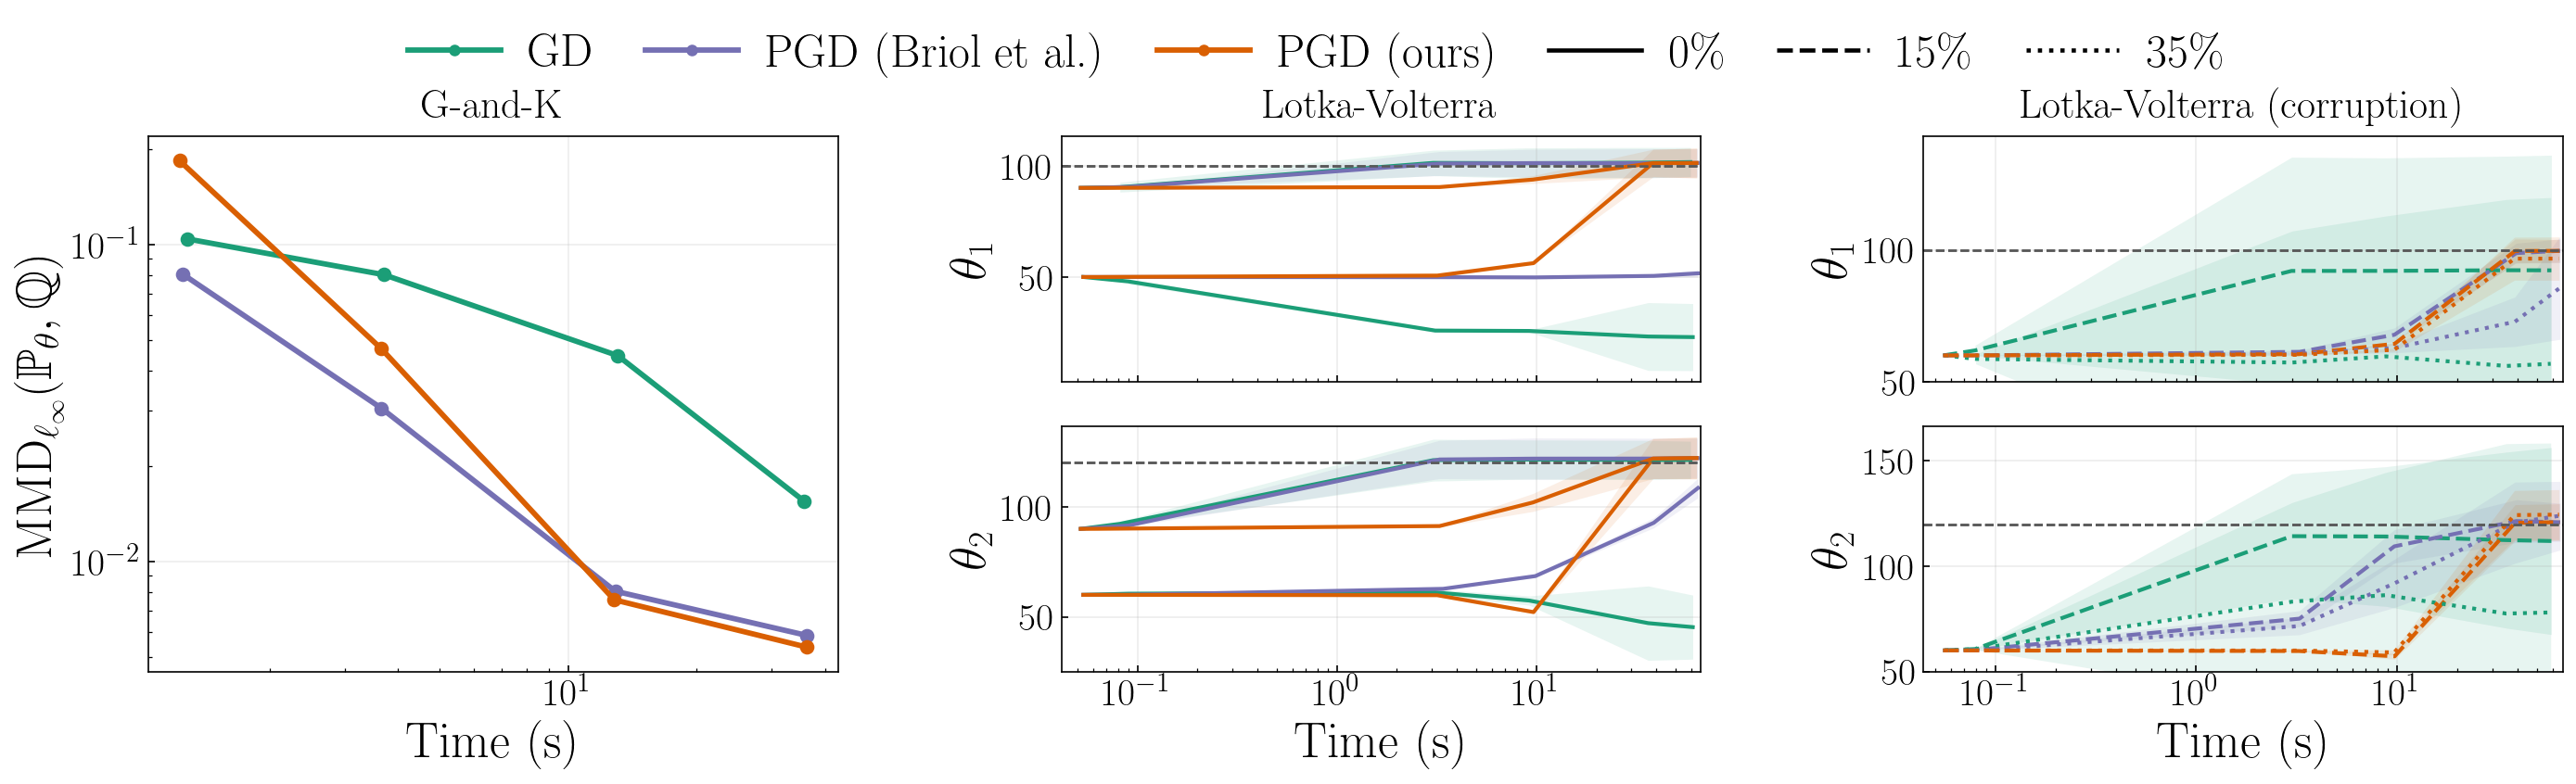

In [23]:
def draw_lv_time_axes(lv_axes, lv_series, title, show_natural=True):
    for record in lv_series["records"]:
        for param_idx, ax in enumerate(lv_axes):
            sgd_time = np.concatenate(([record["init_time"]], record["sgd_time"]))
            sgd_theta = np.concatenate(([record["theta0"][param_idx]], record["sgd_theta"][:, param_idx]))
            pgd_time = np.concatenate(([record["init_time"]], record["pgd_time"]))
            pgd_theta = np.concatenate(([record["theta0"][param_idx]], record["pgd_theta"][:, param_idx]))

            ax.plot(
                sgd_time,
                sgd_theta,
                color=COLORS["gd"],
                linestyle=record["linestyles"]["sgd"],
                linewidth=2.0,
            )
            ax.fill_between(
                record["sgd_time"],
                record["sgd_theta"][:, param_idx] - record["sgd_theta_se"][:, param_idx],
                record["sgd_theta"][:, param_idx] + record["sgd_theta_se"][:, param_idx],
                color=COLORS["gd"],
                alpha=0.10,
                linewidth=0,
            )
            if show_natural and record.get("has_natural", False):
                natural_time = np.concatenate(([record["init_time"]], record["natural_time"]))
                natural_theta = np.concatenate(([record["theta0"][param_idx]], record["natural_theta"][:, param_idx]))
                ax.plot(
                    natural_time,
                    natural_theta,
                    color=COLORS["natural"],
                    linestyle=record["linestyles"].get("natural", "-"),
                    linewidth=2.0,
                )
                ax.fill_between(
                    record["natural_time"],
                    record["natural_theta"][:, param_idx] - record["natural_theta_se"][:, param_idx],
                    record["natural_theta"][:, param_idx] + record["natural_theta_se"][:, param_idx],
                    color=COLORS["natural"],
                    alpha=0.10,
                    linewidth=0,
                )
            ax.plot(
                pgd_time,
                pgd_theta,
                color=COLORS["pgd"],
                linestyle=record["linestyles"]["pgd"],
                linewidth=2.0,
            )
            ax.fill_between(
                record["pgd_time"],
                record["pgd_theta"][:, param_idx] - record["pgd_theta_se"][:, param_idx],
                record["pgd_theta"][:, param_idx] + record["pgd_theta_se"][:, param_idx],
                color=COLORS["pgd"],
                alpha=0.10,
                linewidth=0,
            )
            ax.axhline(float(lv_series["theta_true"][param_idx]), color="0.35", linestyle="--", linewidth=1.2)
            ax.set_ylabel(rf"$\theta_{param_idx + 1}$")
            ax.grid(True, which="major", alpha=0.24, linewidth=0.8)

    for ax in lv_axes:
        ax.set_xscale("log")
        ax.set_xlim(lv_series["left_limit"], lv_series["global_max_time"] * 1.03)
    lv_axes[0].set_title(title, fontsize=21, pad=10)
    lv_axes[0].tick_params(labelbottom=False)
    lv_axes[-1].set_xlabel("Time (s)")


def draw_combined_time_plot(gnk_series, lv_series, lv_corruption_series, output_path=None):
    with plt.rc_context(PLOT_RC):
        fig = plt.figure(figsize=(22.4, 5), dpi=150)
        grid = fig.add_gridspec(2, 3, width_ratios=[1.08, 1.0, 1.0], wspace=0.34, hspace=0.18)
        ax_gnk = fig.add_subplot(grid[:, 0])
        lv_axes = [fig.add_subplot(grid[0, 1]), fig.add_subplot(grid[1, 1], sharex=None)]
        lv_corruption_axes = [fig.add_subplot(grid[0, 2]), fig.add_subplot(grid[1, 2], sharex=None)]

        for series in gnk_series:
            ax_gnk.plot(
                series["time"],
                series["mmd"],
                color=series["color"],
                marker="o",
                linewidth=2.8,
                markersize=6.5,
                label=series["label"],
            )
        ax_gnk.set_xscale("log")
        ax_gnk.set_yscale("log")
        ax_gnk.set_xlabel("Time (s)")
        ax_gnk.set_ylabel(r"$\mathrm{MMD}_{\ell_\infty}(\mathbb{P}_\theta, \mathbb{Q})$")
        ax_gnk.set_title("G-and-K", fontsize=21, pad=10)
        ax_gnk.grid(True, which="major", alpha=0.22, linewidth=0.8)

        draw_lv_time_axes(lv_axes, lv_series, "Lotka-Volterra")
        draw_lv_time_axes(lv_corruption_axes, lv_corruption_series, "Lotka-Volterra (corruption)", show_natural=True)
        for ax in lv_corruption_axes:
            upper = ax.get_ylim()[1]
            ax.set_ylim(bottom=50.0, top=upper)

        top_handles = [
            Line2D([0], [0], color=COLORS["gd"], lw=2.8, marker="o", label="GD"),
            Line2D([0], [0], color=COLORS["natural"], lw=2.8, marker="o", label="PGD (Briol et al.)"),
            Line2D([0], [0], color=COLORS["pgd"], lw=2.8, marker="o", label="PGD (ours)"),
            Line2D([0], [0], color="black", lw=2.2, linestyle=CORRUPTION_LINESTYLES["0"], label="0\%"),
            Line2D([0], [0], color="black", lw=2.2, linestyle=CORRUPTION_LINESTYLES["15"], label="15\%"),
            Line2D([0], [0], color="black", lw=2.2, linestyle=CORRUPTION_LINESTYLES["35"], label="35\%"),
        ]
        fig.legend(
            top_handles,
            [handle.get_label() for handle in top_handles],
            loc="upper center",
            bbox_to_anchor=(0.5, 1.09),
            ncol=6,
            frameon=False,
            fontsize=24,
            columnspacing=1.1,
            handletextpad=0.6,
        )

        if output_path is not None:
            fig.savefig(output_path, bbox_inches="tight")
            print(f"Saved figure to {output_path}")
        return fig


fig = draw_combined_time_plot(gnk_series, lv_series, lv_corruption_series, output_path=OUTPUT_FIGURE)
plt.show()


